# Dogleg vs Levenberg-Marquardt

Most examples in this series use `LevenbergMarquardtOptimizer` without asking whether it's the best choice. GTSAM also ships `DoglegOptimizer`, a different trust-region strategy for nonlinear least squares. This notebook -- inspired by [GitHub issue #452](https://github.com/borglab/gtsam/issues/452) -- empirically compares how often each optimizer actually finds the true optimum as the initial guess gets progressively worse.

The test problem is a small loop-closure graph with a known ground truth: two "rows" of two poses each, pinned by priors, connected by odometry within each row, and tied together diagonally by a single range measurement. That range factor makes the cost landscape trickier than a simple chain -- exactly the kind of case where trust-region strategy matters.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/DogLegOptimizerExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import math

import gtsam
import matplotlib.pyplot as plt
import numpy as np

## 1. Ground truth and factor graph

Four ground-truth poses, `T11`/`T12` and `T21`/`T22`, form two parallel unit-length "rows". Priors pin `T11` and `T21`; `BetweenFactor`s provide odometry within each row; a single `RangeFactorPose2` between `T12` and `T22` (ground-truth distance `1.0`) closes the loop diagonally. This graph -- and specifically that range factor -- is what makes the problem interesting: it's non-convex enough that a bad initial guess can pull an optimizer toward the wrong local solution.

In [3]:
# Ground truth solution
T11 = gtsam.Pose2(0, 0, 0)
T12 = gtsam.Pose2(1, 0, 0)
T21 = gtsam.Pose2(0, 1, 0)
T22 = gtsam.Pose2(1, 1, 0)

# Factor graph
graph = gtsam.NonlinearFactorGraph()

# Priors
prior = gtsam.noiseModel.Isotropic.Sigma(3, 1)
graph.add(gtsam.PriorFactorPose2(11, T11, prior))
graph.add(gtsam.PriorFactorPose2(21, T21, prior))

# Odometry
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.3]))
graph.add(gtsam.BetweenFactorPose2(11, 12, T11.between(T12), model))
graph.add(gtsam.BetweenFactorPose2(21, 22, T21.between(T22), model))

# Range
model_rho = gtsam.noiseModel.Isotropic.Sigma(1, 0.01)
graph.add(gtsam.RangeFactorPose2(12, 22, 1.0, model_rho))

## 2. Monte Carlo comparison setup

For each noise level `sigma` in a fixed list, we run `num_samples` independent trials. Each trial perturbs every ground-truth pose by Gaussian noise of that magnitude (`retract` applies the noise as a manifold perturbation), then runs both `DoglegOptimizer` and `LevenbergMarquardtOptimizer` from the same noisy start. A run "succeeds" if the optimizer converges to (near) zero graph error -- i.e. back to the true global optimum, not stuck somewhere else.

The success probability at each sigma is estimated with a Bayesian Beta(0.5, 0.5) prior (Jeffreys' prior), which gives a well-behaved uncertainty estimate even when the observed success rate is 0% or 100%.

In [4]:
num_samples = 1000
delta = 10.0  # initial trust-region radius for Dogleg

params = gtsam.DoglegParams()
params.setDeltaInitial(delta)  # default is 10

# Add progressively more noise to ground truth
sigmas = [0.01, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20]
n = len(sigmas)
p_dl, s_dl, p_lm, s_lm = [0]*n, [0]*n, [0]*n, [0]*n
for i, sigma in enumerate(sigmas):
    dl_fails, lm_fails = 0, 0
    # Attempt num_samples optimizations for both DL and LM
    for _attempt in range(num_samples):
        initial = gtsam.Values()
        initial.insert(11, T11.retract(np.random.normal(0, sigma, 3)))
        initial.insert(12, T12.retract(np.random.normal(0, sigma, 3)))
        initial.insert(21, T21.retract(np.random.normal(0, sigma, 3)))
        initial.insert(22, T22.retract(np.random.normal(0, sigma, 3)))

        # Run dogleg optimizer
        dl = gtsam.DoglegOptimizer(graph, initial, params)
        result = dl.optimize()
        dl_fails += graph.error(result) > 1e-9

        # Run LM
        lm = gtsam.LevenbergMarquardtOptimizer(graph, initial)
        result = lm.optimize()
        lm_fails += graph.error(result) > 1e-9

    # Calculate Bayes estimate of success probability
    # using a beta prior of alpha=0.5, beta=0.5
    alpha, beta = 0.5, 0.5
    v = num_samples+alpha+beta
    p_dl[i] = (num_samples-dl_fails+alpha)/v
    p_lm[i] = (num_samples-lm_fails+alpha)/v

    def stddev(p):
        """Calculate standard deviation."""
        return math.sqrt(p*(1-p)/(1+v))

    s_dl[i] = stddev(p_dl[i])
    s_lm[i] = stddev(p_lm[i])

    fmt = "sigma= {}:\tDL success {:.2f}% +/- {:.2f}%, LM success {:.2f}% +/- {:.2f}%"
    print(fmt.format(sigma,
                     100*p_dl[i], 100*s_dl[i],
                     100*p_lm[i], 100*s_lm[i]))

sigma= 0.01:	DL success 99.95% +/- 0.07%, LM success 99.95% +/- 0.07%


sigma= 0.1:	DL success 99.95% +/- 0.07%, LM success 99.95% +/- 0.07%


sigma= 0.2:	DL success 99.95% +/- 0.07%, LM success 99.95% +/- 0.07%


sigma= 0.5:	DL success 99.25% +/- 0.27%, LM success 97.75% +/- 0.47%


sigma= 1:	DL success 79.87% +/- 1.27%, LM success 74.28% +/- 1.38%


sigma= 2:	DL success 58.39% +/- 1.56%, LM success 50.10% +/- 1.58%


sigma= 5:	DL success 62.49% +/- 1.53%, LM success 53.40% +/- 1.58%


sigma= 10:	DL success 61.69% +/- 1.54%, LM success 46.40% +/- 1.58%


sigma= 20:	DL success 66.68% +/- 1.49%, LM success 49.80% +/- 1.58%


## 3. Plot

The error bars show \(\pm 1\) posterior standard deviation around the estimated success probability at each noise level.

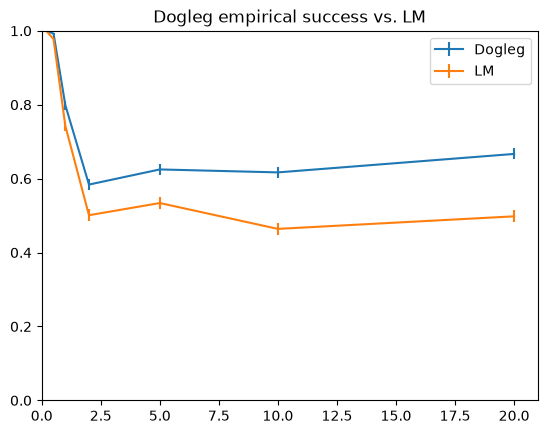

In [5]:
fig, ax = plt.subplots()
dl_plot = plt.errorbar(sigmas, p_dl, yerr=s_dl, label="Dogleg")
lm_plot = plt.errorbar(sigmas, p_lm, yerr=s_lm, label="LM")
plt.title("Dogleg empirical success vs. LM")
plt.legend(handles=[dl_plot, lm_plot])
ax.set_xlim(0, sigmas[-1]+1)
ax.set_ylim(0, 1)
plt.show()

This is a Monte Carlo experiment with no fixed random seed, so the exact numbers will differ every time this notebook runs -- but the qualitative pattern is the point: at small noise both optimizers succeed essentially every time, and as the initial guess gets worse, Dogleg's trust-region approach tends to hold up at least as well as, and often better than, Levenberg-Marquardt on this particular loop-closure geometry.